# 02 · Frequência, Ganhos e Retenção

Antes de segmentar ou modelar qualquer coisa, este notebook constrói e audita os três KPIs centrais que a operação de incentivo acompanha: frequência de engajamento, ganhos gerados e retenção. O objetivo é o mesmo de qualquer painel de acompanhamento de programa de incentivo, entender o comportamento normal antes de decidir o que é abaixo do esperado.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJECT_ROOT / "data"
REPORTS = PROJECT_ROOT / "reports"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

df = pd.read_csv(DATA / "ifood_clean.csv")
df.shape

(2021, 42)

## 1. Frequência de engajamento

A frequência é a soma de compras em todos os canais disponíveis: web, catálogo, loja física e promoções. É a métrica mais direta de quanto o cliente está ativo dentro do programa.

In [2]:
df.frequencia_total.describe()

count    2021.000000
mean       14.897575
std         7.598261
min         0.000000
25%         8.000000
50%        15.000000
75%        21.000000
max        43.000000
Name: frequencia_total, dtype: float64

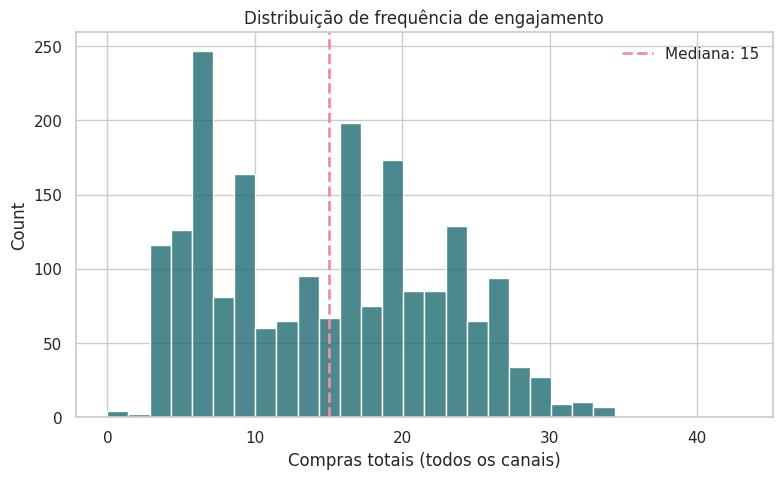

In [3]:
fig, eixo = plt.subplots(figsize=(9, 5))
sns.histplot(df.frequencia_total, bins=30, color=TEAL, ax=eixo)
eixo.axvline(df.frequencia_total.median(), color=CORAL, linestyle="--", linewidth=2, label=f"Mediana: {df.frequencia_total.median():.0f}")
eixo.set(title="Distribuição de frequência de engajamento", xlabel="Compras totais (todos os canais)")
eixo.legend(frameon=False)
plt.show()

## 2. Ganhos gerados

`ganhos_gerados` é o gasto total do cliente em todas as categorias de produto. É a métrica que, num programa de incentivo real, se traduziria em receita ou em ganho do parceiro incentivado.

In [4]:
df.ganhos_gerados.describe()

count    2021.000000
mean      563.789213
std       576.775749
min         4.000000
25%        55.000000
50%       343.000000
75%       964.000000
max      2491.000000
Name: ganhos_gerados, dtype: float64

In [5]:
categorias = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
composicao = df[categorias].sum().sort_values(ascending=False)
composicao_pct = (composicao / composicao.sum() * 100).round(1)
pd.DataFrame({"total_gasto": composicao, "percentual": composicao_pct})

,total_gasto,percentual
MntWines,619421,50.4
MntMeatProducts,335607,27.3
MntGoldProds,88766,7.2
MntFishProducts,75997,6.2
MntSweetProducts,55110,4.5
MntFruits,53283,4.3


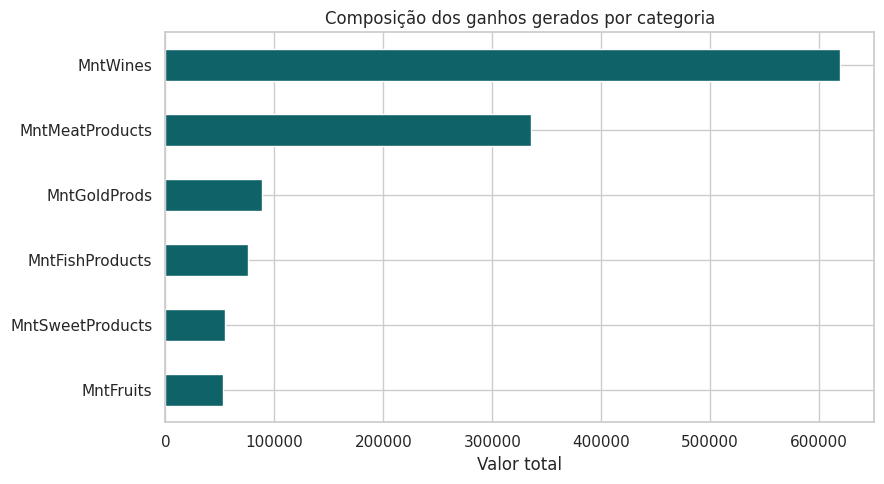

In [6]:
fig, eixo = plt.subplots(figsize=(9, 5))
composicao.sort_values().plot.barh(ax=eixo, color=TEAL)
eixo.set(title="Composição dos ganhos gerados por categoria", xlabel="Valor total")
plt.tight_layout()
plt.show()

## 3. Retenção e risco de queda de engajamento

`Recency`, dias desde a última interação, é usada como proxy inverso de retenção. Quanto maior o valor, maior o risco de o cliente estar se afastando do programa. Definimos uma faixa de risco simples, no mesmo espírito de um alerta operacional: clientes acima do terceiro quartil de `Recency` entram em `risco_de_queda`.

In [7]:
limite_risco = df.Recency.quantile(0.75)
df["risco_de_queda"] = df.Recency.gt(limite_risco)
pd.Series({
    "limite_de_recencia_para_risco": limite_risco,
    "clientes_em_risco": df.risco_de_queda.sum(),
    "percentual_em_risco": df.risco_de_queda.mean(),
})

limite_de_recencia_para_risco     74.000000
clientes_em_risco                491.000000
percentual_em_risco                0.242949
dtype: float64

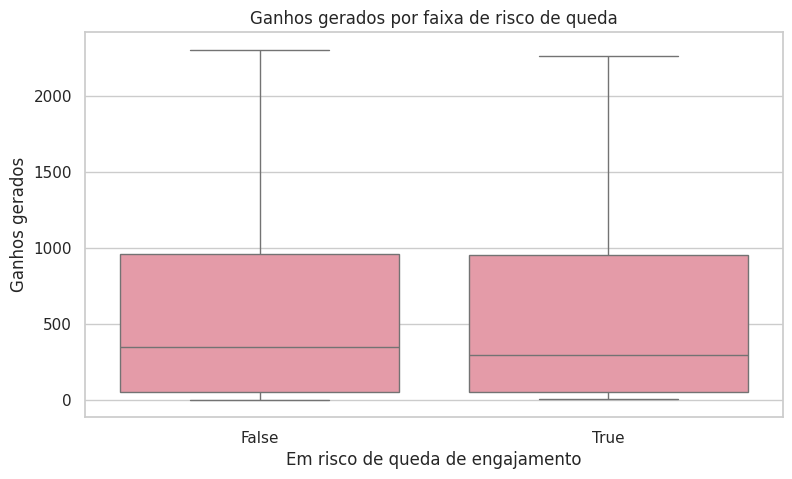

In [8]:
fig, eixo = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="risco_de_queda", y="ganhos_gerados", color=CORAL, showfliers=False, ax=eixo)
eixo.set(title="Ganhos gerados por faixa de risco de queda", xlabel="Em risco de queda de engajamento", ylabel="Ganhos gerados")
plt.show()

## 4. KPI consolidado, por trimestre simulado de tempo de casa

Sem uma data de campanha por linha, não é possível construir uma série temporal real, e essa limitação está registrada abaixo. Como substituto informativo, `Customer_Days`, o tempo de relacionamento, é discretizado em quartis para simular a leitura que um painel mensal faria. O comportamento muda conforme o cliente amadurece na base.

In [9]:
df["faixa_de_relacionamento"] = pd.qcut(df.Customer_Days, 4, labels=["mais novo", "novo", "maduro", "mais antigo"])
painel = df.groupby("faixa_de_relacionamento", observed=True).agg(
    clientes=("Income", "size"),
    frequencia_media=("frequencia_total", "mean"),
    ganhos_medios=("ganhos_gerados", "mean"),
    taxa_de_resposta=("Response", "mean"),
).round(2)
painel

,clientes,frequencia_media,ganhos_medios,taxa_de_resposta
faixa_de_relacionamento,,,,
mais novo,507,12.83,460.57,0.09
novo,507,14.12,504.66,0.10
maduro,507,15.85,600.41,0.16
mais antigo,500,16.82,691.28,0.27


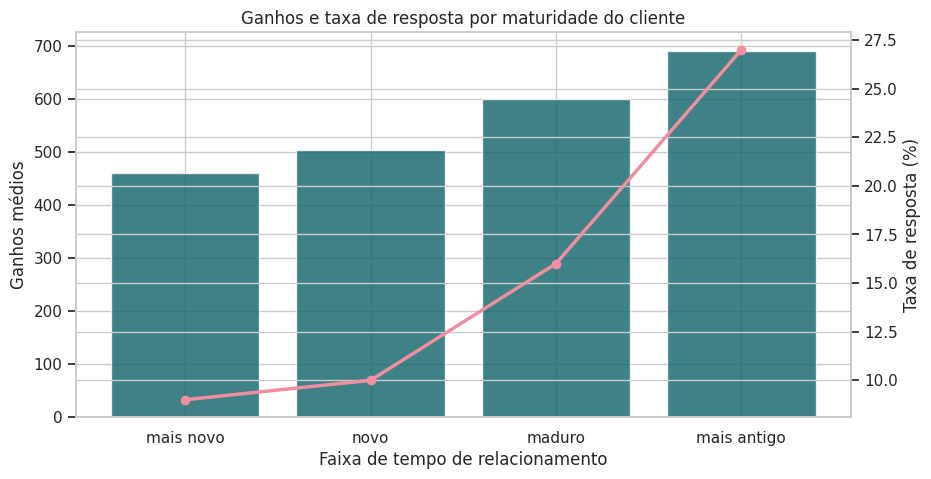

In [10]:
fig, eixo = plt.subplots(figsize=(10, 5))
eixo2 = eixo.twinx()
eixo.bar(painel.index.astype(str), painel.ganhos_medios, color=TEAL, alpha=.8)
eixo2.plot(painel.index.astype(str), painel.taxa_de_resposta * 100, color=CORAL, marker="o", linewidth=2.5)
eixo.set(ylabel="Ganhos médios", xlabel="Faixa de tempo de relacionamento", title="Ganhos e taxa de resposta por maturidade do cliente")
eixo2.set_ylabel("Taxa de resposta (%)")
plt.show()

## Limitação

O dataset não tem carimbo de data por transação nem por campanha. Só existe `Dt_Customer`, a data de entrada, e `Recency`, dias desde a última compra, relativos a uma data de referência que não está documentada. Por isso este notebook usa maturidade de relacionamento como substituto de série temporal real, e deixa isso explícito em vez de simular uma tendência mensal que os dados não sustentam.

## Conclusão

Os três KPIs centrais, frequência, ganhos e retenção, têm variação real e mensurável entre grupos de clientes. Isso justifica os dois próximos passos: segmentar formalmente esses clientes no notebook 03 e testar se resposta a incentivo se relaciona de forma estatisticamente robusta com esses mesmos KPIs no notebook 04.